# VHDL / RTL Concepts in Python + SymPy `init_printing`

**Three levels of digital abstraction** (Quartus / IEEE 1076):

| Level | Description | VHDL construct |
|-------|-------------|----------------|
| 0 — Gate | Boolean algebra, AND/OR/XOR gates | `std_logic`, `and`, `or` |
| 1 — RTL | Registers + datapath ops between clock edges | `process(clk)`, `<=` |
| 2 — Behavioural | Algorithm-level, synthesizer maps to RTL | `process`, `if/case` |

This notebook covers all three using `dgs/vhdl_rtl.py` (pure Python / SymPy — no VHDL compiler needed).
The mathematics is identical to what Quartus synthesises; only the syntax differs.


## §2 IEEE std_logic — 9-value system

`std_logic` replaces binary 0/1 with a 9-state type (IEEE 1164):

```
U  X  0  1  Z  W  L  H  -
```

`Z` = high-impedance (tri-state bus), `X` = unknown (metastability),
`U` = uninitialised (simulation only), `-` = don't-care (synthesis).
The **resolution function** decides what a wire reads when two drivers conflict.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from dgs.vhdl_rtl import (
    std_logic_resolve, std_logic_and, std_logic_or, std_logic_not,
    slv_to_int, int_to_slv,
    STD_LOGIC_VALUES,
)

# Resolution table demo
pairs = [("0","1"), ("1","Z"), ("0","Z"), ("Z","Z"), ("X","0"), ("U","1")]
print("std_logic resolution table:")
for a, b in pairs:
    print(f"  resolve('{a}', '{b}') = {std_logic_resolve(a, b)}")

print()
print("Gate truth with 9-value logic:")
print(f"  AND('X','0') = {std_logic_and('X','0')}  <- dominating 0")
print(f"  OR('1','X')  = {std_logic_or('1','X')}  <- dominating 1")
print(f"  NOT('Z')     = {std_logic_not('Z')}  <- unknown")


std_logic resolution table:
  resolve('0', '1') = X
  resolve('1', 'Z') = 1
  resolve('0', 'Z') = 0
  resolve('Z', 'Z') = Z
  resolve('X', '0') = X
  resolve('U', '1') = X

Gate truth with 9-value logic:
  AND('X','0') = 0  <- dominating 0
  OR('1','X')  = 1  <- dominating 1
  NOT('Z')     = X  <- unknown


## §3 Combinational Logic: Full Adder

Combinational = **no clock, output depends only on current inputs**.

Full adder VHDL:
```vhdl
S    <= A xor B xor Cin;
Cout <= (A and B) or (B and Cin) or (A and Cin);
```

We verify this with a truth table and SymPy Boolean simplification.


In [2]:
from dgs.vhdl_rtl import build_full_adder_block
import sympy as sp
from sympy.logic.boolalg import Xor, simplify_logic

fa = build_full_adder_block()
print("Full adder truth table:")
print(fa.truth_table_str())

# SymPy Boolean verification
A, B, Cin = sp.symbols("A B Cin")
sum_expr = Xor(Xor(A, B), Cin)
cout_expr = (A & B) | (B & Cin) | (A & Cin)
print()
print(f"Sum  (simplified) = {simplify_logic(sum_expr)}")
print(f"Cout (simplified) = {simplify_logic(cout_expr)}")


Full adder truth table:
A B Cin | Sum Cout
------------------
0 0 0 | 0 0
0 0 1 | 1 0
0 1 0 | 1 0
0 1 1 | 0 1
1 0 0 | 1 0
1 0 1 | 0 1
1 1 0 | 0 1
1 1 1 | 1 1

Sum  (simplified) = (A & B & Cin) | (A & ~B & ~Cin) | (B & ~A & ~Cin) | (Cin & ~A & ~B)
Cout (simplified) = (A & B) | (A & Cin) | (B & Cin)


## §4 Sequential Logic: D Flip-Flop and Register

Sequential = **state depends on clock history**.

VHDL positive-edge D-FF:
```vhdl
process(clk)
begin
  if rising_edge(clk) then
    if rst = '1' then Q <= '0';
    else               Q <= D;
    end if;
  end if;
end process;
```

`Q` only updates on the rising edge — everything else is held in the register.


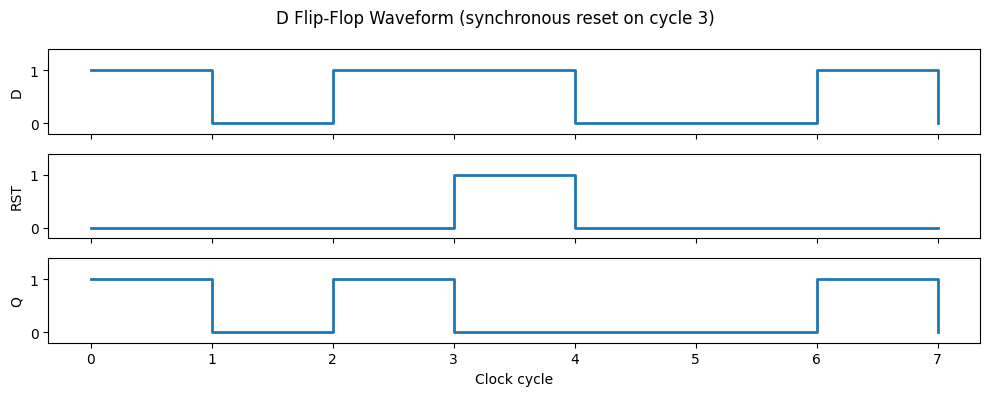

Q trace: [1, 0, 1, 0, 0, 0, 1, 0]
Register Q = 10110010 = 178
After RST  = 00000000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dgs.vhdl_rtl import DFlipFlop, Register

dff = DFlipFlop(init=0)
D_in  = [1, 0, 1, 1, 0, 0, 1, 0]
rst   = [0, 0, 0, 1, 0, 0, 0, 0]
Q_out = dff.simulate(D_in, rst)

cycles = range(len(D_in))
fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
for ax, sig, label in zip(axes, [D_in, rst, Q_out], ["D", "RST", "Q"]):
    ax.step(cycles, sig, where="post", lw=2)
    ax.set_ylim(-0.2, 1.4)
    ax.set_ylabel(label)
    ax.set_yticks([0, 1])
axes[-1].set_xlabel("Clock cycle")
fig.suptitle("D Flip-Flop Waveform (synchronous reset on cycle 3)")
plt.tight_layout()
plt.savefig("vhdl_dff_wave.png", dpi=90)
plt.show()
print("Q trace:", Q_out)

# 8-bit register
reg = Register(8)
reg.load(0b10110010)
print(f"Register Q = {reg.read_slv()} = {reg.read()}")
reg.load(0, rst=1)
print(f"After RST  = {reg.read_slv()}")


## §5 Finite State Machine — Moore Traffic Light

**Moore FSM**: output depends only on current **state** (not input).
**Mealy FSM**: output depends on state AND input.

VHDL equivalent (two-process Moore template):
```vhdl
-- State register process
process(clk) begin
  if rising_edge(clk) then
    current_state <= next_state;
  end if;
end process;

-- Combinational next-state + output decode
process(current_state, timer_expired) begin
  case current_state is
    when GREEN  => output <= "01"; if timer_expired then next_state <= YELLOW; end if;
    when YELLOW => output <= "10"; if timer_expired then next_state <= RED;    end if;
    when RED    => output <= "11"; if timer_expired then next_state <= GREEN;  end if;
  end case;
end process;
```


In [4]:
from dgs.vhdl_rtl import build_traffic_light_fsm

fsm = build_traffic_light_fsm()
print(fsm.transition_diagram_str())
print()

inputs = [1, 1, 1, 0, 0, 1, 1]
lights = [fsm.outputs[fsm.initial]] + fsm.run(inputs)
print(f"Timer events: {inputs}")
print(f"Light colors: {lights}")


FSM Transition Diagram
  GREEN (out=green) [INIT]
    --0--> GREEN
    --1--> YELLOW
  YELLOW (out=yellow)
    --0--> YELLOW
    --1--> RED
  RED (out=red)
    --0--> RED
    --1--> GREEN

Timer events: [1, 1, 1, 0, 0, 1, 1]
Light colors: ['green', 'yellow', 'red', 'green', 'green', 'green', 'yellow', 'red']


## §6 Sequence Detector '101' with State Trace

Detect the bit pattern `101` in a serial bitstream (overlapping detection).
4 states: S0 (idle) → S1 (got 1) → S2 (got 10) → S3 (got 101, output=1).

This is a classic sequential circuit for VHDL labs and IEEE Std 1076 examples.


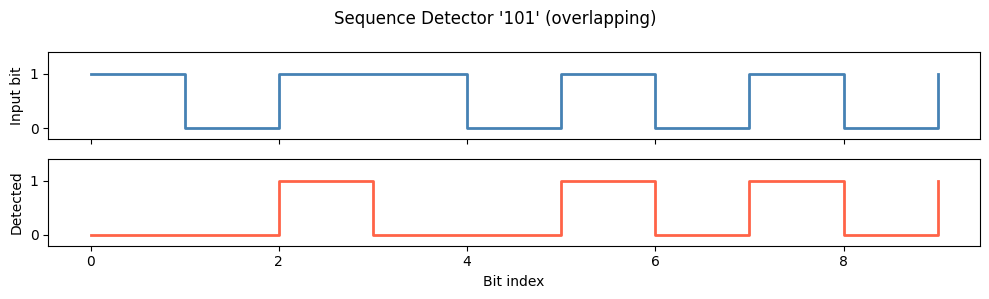

Detections at indices: [2, 5, 7, 9]


In [5]:
import matplotlib.pyplot as plt
from dgs.vhdl_rtl import build_sequence_detector_fsm

det = build_sequence_detector_fsm()
bits = [1, 0, 1, 1, 0, 1, 0, 1, 0, 1]
detected = det.run(bits)

fig, axes = plt.subplots(2, 1, figsize=(10, 3), sharex=True)
axes[0].step(range(len(bits)), bits, where="post", lw=2, color="steelblue")
axes[0].set_ylabel("Input bit"); axes[0].set_ylim(-0.2, 1.4)
axes[1].step(range(len(detected)), detected, where="post", lw=2, color="tomato")
axes[1].set_ylabel("Detected"); axes[1].set_ylim(-0.2, 1.4)
axes[-1].set_xlabel("Bit index")
fig.suptitle("Sequence Detector '101' (overlapping)")
plt.tight_layout()
plt.savefig("vhdl_seq_detect.png", dpi=90)
plt.show()
print("Detections at indices:", [i for i,d in enumerate(detected) if d])


## §7 RTL Datapath: 8-bit ALU

Register-Transfer Level = **registers + operations between clock edges**.

ALU opcodes (3-bit `op_sel`):
```
000=ADD  001=SUB  010=AND  011=OR
100=XOR  101=NOT_A  110=SHL  111=SHR
```

Flags: **Z** (zero), **N** (negative/MSB), **C** (carry out), **V** (overflow).


In [6]:
from dgs.vhdl_rtl import ALU

alu = ALU(width=8)
ops = [
    (10, 3,  0b000, "ADD"),
    (10, 3,  0b001, "SUB"),
    (0b11001100, 0b10101010, 0b010, "AND"),
    (3,  5,  0b001, "SUB 3-5 (negative)"),
    (0b10110100, 0, 0b101, "NOT A"),
    (0b00000011, 0, 0b110, "SHL x1"),
]
print(f"{'Op':<18} {'A':>10} {'B':>10} {'Result':>8}  ZNVC")
print("-" * 58)
for A, B, op_code, label in ops:
    res, flags = alu.execute(A, B, op_code)
    f = f"{flags['Z']}{flags['N']}{flags['C']}{flags['V']}"
    print(f"{label:<18} {A:>10} {B:>10} {res:>8}  {f}")


Op                          A          B   Result  ZNVC
----------------------------------------------------------
ADD                        10          3       13  0000
SUB                        10          3        7  0000
AND                       204        170      136  0100
SUB 3-5 (negative)          3          5      254  0100
NOT A                     180          0       75  0000
SHL x1                      3          0        6  0000


## §8 SymPy RTL: Pipeline Timing Analysis

A pipelined datapath inserts **registers between combinational stages**.

Clock period: $T_{clk} = \max(d_1, d_2, ..., d_N) + t_{reg}$

- Throughput: 1 result per clock cycle (after pipeline fills)
- Latency: $N \cdot T_{clk}$ (N stages to compute first result)

SymPy gives us exact symbolic expressions — no numbers needed.


In [7]:
import sympy as sp
sp.init_printing(use_latex=False)

from dgs.vhdl_rtl import rtl_pipeline_sympy

pipe = rtl_pipeline_sympy(4)
print(f"Clock period  T_clk   = {pipe['T_clock']}")
print(f"Latency (4 stages)    = {pipe['latency']}")
print(f"Throughput            = {pipe['throughput']}")

# Numerical: d1=2ns, d2=3ns, d3=2.5ns, d4=1.8ns, t_reg=0.5ns
d_vals = {pipe['stage_delays'][i]: v for i, v in enumerate([2.0, 3.0, 2.5, 1.8])}
t_val = {sp.Symbol('t_reg', positive=True): 0.5}
subs = {**d_vals, **t_val}
T_num = float(pipe['T_clock'].subs(subs))
lat_num = float(pipe['latency'].subs(subs))
print(f"\nWith d=[2,3,2.5,1.8] ns, t_reg=0.5 ns:")
print(f"  T_clk  = {T_num} ns  -> f_max = {1000/T_num:.0f} MHz")
print(f"  Latency= {lat_num} ns")


Clock period  T_clk   = t_reg + Max(d_1, d_2, d_3, d_4)
Latency (4 stages)    = 4*t_reg + 4*Max(d_1, d_2, d_3, d_4)
Throughput            = 1/(t_reg + Max(d_1, d_2, d_3, d_4))

With d=[2,3,2.5,1.8] ns, t_reg=0.5 ns:
  T_clk  = 3.5 ns  -> f_max = 286 MHz
  Latency= 14.0 ns


## §9 Work-Energy Theorem — 5 Key Equations with `sp.init_printing`

The **work-energy theorem** in mechanics:

$$W_{net} = \Delta KE = \frac{1}{2}mv_f^2 - \frac{1}{2}mv_i^2$$

This is the mechanical analogue of RTL power dissipation:
$E_{op} = C_{load} \cdot V_{DD}^2$ per switching event.

Five symbolic results:


In [8]:
import sympy as sp
sp.init_printing(use_latex=False)   # ASCII-safe on Windows (no cp1252 issues)

from dgs.vhdl_rtl import work_energy_sympy

we = work_energy_sympy()

print("=" * 55)
print("WORK-ENERGY THEOREM: 5 Key Symbolic Results")
print("=" * 55)

labels = [
    ("KE", "Kinetic energy"),
    ("W_net = DeltaKE", "Work-energy theorem (W_net = delta_KE)"),
    ("W_grav", "Work by gravity"),
    ("W_friction", "Work by kinetic friction (negative)"),
    ("conservation_with_friction", "Energy conservation with friction"),
]

for key, desc in labels:
    print(f"\n  [{desc}]")
    print(f"    {we[key]}")

print("\n  [vf from net work done]")
print(f"    {we['vf_from_work']}")



WORK-ENERGY THEOREM: 5 Key Symbolic Results

  [Kinetic energy]
    m*v**2/2

  [Work-energy theorem (W_net = delta_KE)]
    Eq(F*d, -m*v_0**2/2 + m*v_f**2/2)

  [Work by gravity]
    g*h*m

  [Work by kinetic friction (negative)]
    -N*d*mu

  [Energy conservation with friction]
    Eq(-N*d*mu + g*h*m + m*v_0**2/2, m*v_f**2/2)

  [vf from net work done]
    Eq(v_f, sqrt(2*W_net/m + v_0**2))


## §10 RTL Energy per Operation — Connecting Physics to Digital Design

CMOS dynamic power: $P = \alpha \cdot C_L \cdot V_{DD}^2 \cdot f_{clk}$

- $\alpha$ = activity factor (fraction of gates switching per cycle)
- $C_L$ = load capacitance (femtofarads)
- $V_{DD}$ = supply voltage
- $f_{clk} = 1/T_{clk}$

Energy per operation = $E_{op} = \alpha C_L V_{DD}^2$
Same form as $W = \frac{1}{2}mv^2$ — quadratic in the "potential" ($V_{DD}$ vs $v$).

Reducing $V_{DD}$ from 1.8 V → 0.9 V cuts dynamic power by **4×** (quadratic).
This is why sub-threshold CMOS and near-threshold computing are active research areas.


CMOS dynamic power:
  P = C_L*V_DD**2*alpha*f_clk
  E_op per switch = C_L*V_DD**2*alpha


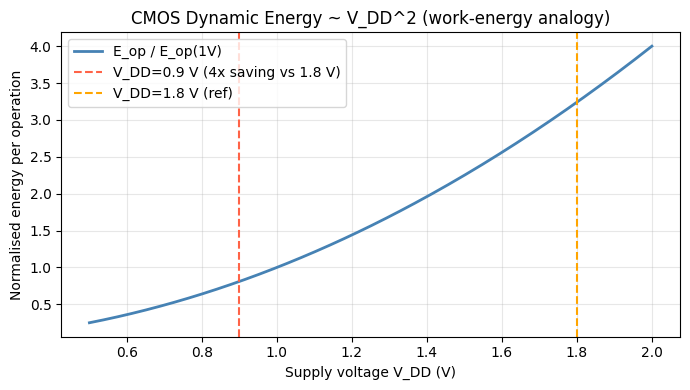


E_op at 0.9V / E_op at 1.8V = 0.250  (~4x saving)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing(use_latex=False)

alpha, C_L, V_DD, f_clk = sp.symbols("alpha C_L V_DD f_clk", positive=True)
P_dyn = alpha * C_L * V_DD**2 * f_clk
E_op  = alpha * C_L * V_DD**2

print("CMOS dynamic power:")
print(f"  P = {P_dyn}")
print(f"  E_op per switch = {E_op}")

# Numeric sweep: V_DD 0.5 -> 2.0 V
Vdd_arr = np.linspace(0.5, 2.0, 200)
E_norm  = (Vdd_arr / 1.0)**2   # normalised to 1 V reference

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Vdd_arr, E_norm, lw=2, color="steelblue", label="E_op / E_op(1V)")
ax.axvline(0.9, color="tomato", ls="--", label="V_DD=0.9 V (4x saving vs 1.8 V)")
ax.axvline(1.8, color="orange", ls="--", label="V_DD=1.8 V (ref)")
ax.set_xlabel("Supply voltage V_DD (V)")
ax.set_ylabel("Normalised energy per operation")
ax.set_title("CMOS Dynamic Energy ~ V_DD^2 (work-energy analogy)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vhdl_cmos_energy.png", dpi=90)
plt.show()

print(f"\nE_op at 0.9V / E_op at 1.8V = {(0.9/1.8)**2:.3f}  (~4x saving)")
